# Tasca S10.01. Analítica de datos en Pandas
## Nivel 1

### Ejercicio 1.

Importa el archivo sprint10.xlsx como un DataFrame.

Asegúrate de que el archivo se importe correctamente, con los nombres de columnas correspondientes, sin modificar el archivo original.

Ordena el DataFrame por el país de origen.
En caso de empate, ordénalo por el nombre de la ciudad.
Muestra las primeras 10 filas.

Adicionalmente, realiza un print que compruebe que el DNI contiene únicamente valores únicos.

# IMPORTACIONES

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# un paso anterior se realizo a instalacion de !pip install openpyxl

In [2]:
df = pd.read_excel( 
    "sprint10.xlsx",
    header=3 # cambia la pocision de las filas, al usar esta columna me permitio posicionar los encabezados correctos en la primera posicion
)

In [3]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   Nom                1000 non-null   str    
 2   Cognoms            1000 non-null   str    
 3   DNI                1000 non-null   str    
 4   País d'origen      1000 non-null   str    
 5   Ciutat             1000 non-null   str    
 6   Dia de Naixement   1000 non-null   int64  
 7   Mes de Naixement   1000 non-null   int64  
 8   Any de Naixement   1000 non-null   int64  
 9   Gènere             1000 non-null   str    
 10  Salari mensual     1000 non-null   str    
 11  Fills              406 non-null    float64
 12  No Fills           594 non-null    float64
 13  Grup Professional  1000 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 109.5 KB


In [4]:
df = df.sort_values( # ordena por columna, me permitio decidir el orden prioritario (asc o des)
    by=["País d'origen", "Ciutat"],
    ascending=True
)
df.head(10)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [5]:
if df["DNI"].is_unique: # asi mismo degterminar si en la identificacion existe duplicados
    print('no hay DNI repetidos')
else:
    print('hay DNI repetidos')


no hay DNI repetidos


### 2. 
Crea una columna con el nombre completo.
Crea una columna que indique si la persona nació en España o no.
Establece el DNI como índice del DataFrame (nombres de fila).
Sustituye los nombres de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.
Sustituye:
H → Hombre
D → Mujer
A → Otros
NC → dato faltante (NaN / null / NA)
Muestra todos los cambios realizados en una única tabla.


In [6]:
df['nombre_completo'] = df['Nom'] + ' '+ df['Cognoms']
df["nacido_espana"] = df["País d'origen"] == "Espanya"
df = df.set_index("DNI")

df = df.rename(columns={
    "Dia de Naixement": "Dia",
    "Mes de Naixement": "Mes",
    "Any de Naixement": "Año"
})

In [7]:
df["Gènere"] = df["Gènere"].replace({
    "H": "Hombre",
    "D": "Mujer",
    "A": "Otros",
    "NC": np.nan
})

df.head(10)

,Unnamed: 0,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,nombre_completo,nacido_espana
DNI,,,,,,,,,,,,,,,
28973553Z,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False
37399141L,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False
37368317L,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False
21390098Z,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Mujer,1.557 €,1.0,NaN,Grup B,Mia Fischer,False
44060014R,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Hombre,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False
14773153R,871,Lea,Fischer,Alemanya,Berlín,9,9,1986,Mujer,1.370 €,1.0,NaN,Grup A,Lea Fischer,False
23266650S,281,Lea,Müller,Alemanya,Hamburg,14,4,2003,Mujer,1.314 €,NaN,1.0,Grup A,Lea Müller,False
83274277X,435,Anna,Müller,Alemanya,Hamburg,1,1,1987,Mujer,2.464 €,NaN,1.0,Grup C,Anna Müller,False
60161784X,444,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2.035 €,1.0,NaN,Grup C,Laura Schmidt Müller,False


### 3
Une las columnas Hijos y Sin Hijos en una sola columna utilizando el método .apply() y definiendo una función que resuelva el problema.

La nueva columna debe llamarse "Hijos" y tomar los valores:

"Sí"
"No"


In [8]:
def rellenar_hijos(fila):
    """
    Devuelve 'Sí' si la columna 'Fills' es True.
    En caso contrario devuelve 'No'.
    """
    if pd.notna(fila["Fills"]):
        return "Si"
    else:
        return "No"

df["Hijos"] = df.apply(rellenar_hijos, axis=1)

df[["Fills", "No Fills", "Hijos"]].head()

,Fills,No Fills,Hijos
DNI,,,
28973553Z,NaN,1.0,No
37399141L,1.0,NaN,Si
37368317L,NaN,1.0,No
21390098Z,1.0,NaN,Si
44060014R,1.0,NaN,Si


In [9]:
df.head(10)

,Unnamed: 0,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,nombre_completo,nacido_espana,Hijos
DNI,,,,,,,,,,,,,,,,
28973553Z,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False,No
37399141L,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False,Si
37368317L,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False,No
21390098Z,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Mujer,1.557 €,1.0,NaN,Grup B,Mia Fischer,False,Si
44060014R,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Hombre,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False,Si
14773153R,871,Lea,Fischer,Alemanya,Berlín,9,9,1986,Mujer,1.370 €,1.0,NaN,Grup A,Lea Fischer,False,Si
23266650S,281,Lea,Müller,Alemanya,Hamburg,14,4,2003,Mujer,1.314 €,NaN,1.0,Grup A,Lea Müller,False,No
83274277X,435,Anna,Müller,Alemanya,Hamburg,1,1,1987,Mujer,2.464 €,NaN,1.0,Grup C,Anna Müller,False,No
60161784X,444,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2.035 €,1.0,NaN,Grup C,Laura Schmidt Müller,False,Si


### 4. 
Crea una tabla resumen que permita visualizar el salario:

medio
mediano
mínimo
máximo

agrupado por género.

Ordena la tabla en función del salario medio.

In [10]:
df["Salari mensual"] = (
    df["Salari mensual"]
    .str.replace(".", "", regex=False)
    .str.replace(" €", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

tabla_resumen = (
    df.groupby("Gènere")["Salari mensual"]
    .agg(
        Media="mean",
        Mediana="median",
        Salario_Minimo="min",
        Salario_Maximo="max"
    ).round(2) 
    .sort_values("Media")
)

tabla_resumen

,Media,Mediana,Salario_Minimo,Salario_Maximo
Gènere,,,,
Mujer,1469.44,1361.5,665.0,3021.0
Otros,1626.59,1545.0,703.0,3175.0
Hombre,1643.25,1531.0,737.0,3356.0


### 5. 
Crea una tabla resumen con el salario medio por:

género (filas)
país de origen (columnas)

Añade las medias en los márgenes de la tabla.

(EXTRA) Aplica formato condicional a la tabla para visualizar con un color más intenso los valores más altos.

In [11]:
tabla_pivot = pd.pivot_table(
    df,
    values="Salari mensual",
    index="Gènere",
    columns="País d'origen",
    aggfunc="mean",
    margins=True,
    margins_name="Promedio"
).round(2)

tabla_pivot

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Promedio
Gènere,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Promedio,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


In [12]:
tabla_pivot.style.background_gradient(cmap="YlOrRd") # \.format('{:.2f'})\ revisar

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Promedio
Gènere,,,,,,,,,,,
Hombre,2067.430000,1583.290000,1554.670000,1682.110000,1389.250000,1672.880000,1531.000000,1625.000000,1497.000000,1162.560000,1643.250000
Mujer,1804.310000,1291.800000,1497.750000,1460.160000,1566.470000,1247.180000,1405.210000,1517.800000,1488.550000,1489.460000,1469.440000
Otros,951.000000,1141.000000,1030.000000,1706.180000,nan,1423.000000,1365.000000,1372.000000,1765.000000,1921.000000,1626.590000
Promedio,1851.380000,1463.390000,1495.540000,1581.210000,1462.730000,1425.950000,1447.330000,1558.420000,1523.330000,1423.560000,1560.990000


### 6. 
Crea una nueva columna con la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año.

Utilizando esta columna, crea una función que, dada una fecha, calcule la edad actual a fecha de hoy.

Utiliza la función que acabas de crear para generar una nueva columna en el DataFrame con la edad actual.



In [14]:
# Crear la columna de fecha de nacimiento
df["Fecha_nacimiento"] = pd.to_datetime(
    {
        "year": df["Año"],
        "month": df["Mes"],
        "day": df["Dia"]
    }
)


def calcular_edad(fecha_nacimiento):
    """
    Calcula la edad actual a partir de una fecha de nacimiento.
    """
    hoy = datetime.today()

    edad = hoy.year - fecha_nacimiento.year

    if (hoy.month, hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day):
        edad -= 1

    return edad


df["Edad"] = df["Fecha_nacimiento"].apply(calcular_edad)

df[["Fecha_nacimiento", "Edad"]].head()

,Fecha_nacimiento,Edad
DNI,,
28973553Z,1976-10-22,49
37399141L,1958-02-02,68
37368317L,2005-10-23,20
21390098Z,1950-08-11,75
44060014R,1985-11-22,40


## Nivel 2
### 1. 
Utilizando el siguiente DataFrame, añade la columna Incremento al DataFrame del nivel anterior.

Actualiza la columna salario según los porcentajes indicados.

No modifiques manualmente los incrementos; escribe código Python para realizar las conversiones necesarias.

df_increment = pd.DataFrame({
    "Grupo": ["Grupo A", "Grupo B", "Grupo C", "Grupo D"],
    "Incremento": ["5%", "3,5%", "2%", "8%"]
})

In [15]:
# Crear el DataFrame con los incrementos
df_increment = pd.DataFrame({
    "Grup Professional": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Incremento": ["5%", "3,5%", "2%", "8%"]
})

# Unir ambos DataFrames
df = df.merge(
    df_increment,
    on="Grup Professional",
    how="left"
)

# Convertir el porcentaje a decimal
df["Incremento"] = (
    df["Incremento"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float) / 100
)

# Actualizar el salario
df["Salari mensual"] = (
    df["Salari mensual"] *
    (1 + df["Incremento"])
).round(2)

df.head()


,Unnamed: 0,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,nombre_completo,nacido_espana,Hijos,Fecha_nacimiento,Edad,Incremento
0,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,998.55,NaN,1.0,Grup A,Mia Schneider Fischer,False,No,1976-10-22,49,0.050
1,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1830.92,1.0,NaN,Grup B,Laura Schneider Fischer,False,Si,1958-02-02,68,0.035
2,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2083.46,NaN,1.0,Grup B,Lea Schneider Schneider,False,No,2005-10-23,20,0.035
3,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Mujer,1611.50,1.0,NaN,Grup B,Mia Fischer,False,Si,1950-08-11,75,0.035
4,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Hombre,2974.32,1.0,NaN,Grup D,Jonas Schneider,False,Si,1985-11-22,40,0.080


### 2. 
Utilizando un bucle, exporta los datos de cada Grupo Profesional en 4 archivos (.xlsx o .csv).

Por ejemplo:

datos_GrupoA.xlsx
datos_GrupoB.xlsx
datos_GrupoC.xlsx
datos_GrupoD.xlsx

Exporta un quinto DataFrame en formato .xlsx o .csv que contenga:

número de trabajadores por Grupo Profesional
salario medio
edad mediana

para cada grupo profesional.



In [16]:
for grupo, datos in df.groupby("Grup Professional"):

    nombre_archivo = grupo.replace(" ", "")

    datos.to_excel(
        f"dades_{nombre_archivo}.xlsx",
        index=False
    )


In [17]:
resumen = (
    df.groupby("Grup Professional")
      .agg(
          Trabajadores=("nombre_completo", "count"),
          Salario_Medio=("Salari mensual", "mean"),
          Edad_Mediana=("Edad", "median")
      )
)

resumen.to_excel(
    "resumen_grupos.xlsx"
)


## Nivel 3

El nivel 3 de este sprint es completamente diferente a los anteriores, ya que consiste en ejercicios más abstractos que requieren un mayor trabajo de razonamiento.

No continúan con el mismo conjunto de datos de los niveles anteriores, sino que plantean dos situaciones nuevas totalmente distintas entre sí.

### 1. 
Crea una función que reciba un DataFrame como parámetro de entrada.

La función debe crear (y exportar) automáticamente un gráfico para cada columna del DataFrame.

Por ejemplo:

Un histograma o boxplot si la variable es numérica.
Un gráfico de barras con los valores más frecuentes si la variable es categórica.
Un gráfico de barras con los años más frecuentes si la variable tiene formato fecha.

La idea es crear una función que funcione con cualquier DataFrame, no solo con el que hemos trabajado hasta ahora.

Muestra el resultado de la función utilizando alguno de los conjuntos de datos de ejemplo incluidos en Seaborn, por ejemplo:

iris
penguins
titanic

Ten en cuenta que en el próximo sprint trabajarás exclusivamente con gráficos. El objetivo de este ejercicio no es crear visualizaciones muy elaboradas, sino resolver una necesidad de forma rápida y automática.

In [ ]:
def graficos_automaticos(df):
    """
    Genera automáticamente un gráfico para cada columna según el tipo de dato.
    """

    for columna in df.columns:

        plt.figure(figsize=(6,4))

        # Variables numéricas
        if pd.api.types.is_numeric_dtype(df[columna]):

            plt.hist(df[columna].dropna(), bins=20)

            plt.title(f"Histograma de {columna}")

        # Variables de tipo fecha
        elif pd.api.types.is_datetime64_any_dtype(df[columna]):

            df[columna].dt.year.value_counts().sort_index().plot(kind="bar")

            plt.title(f"Años de {columna}")

        # Variables categóricas
        else:

            df[columna].value_counts().plot(kind="bar")

            plt.title(f"Frecuencia de {columna}")

        plt.tight_layout()

        plt.show()


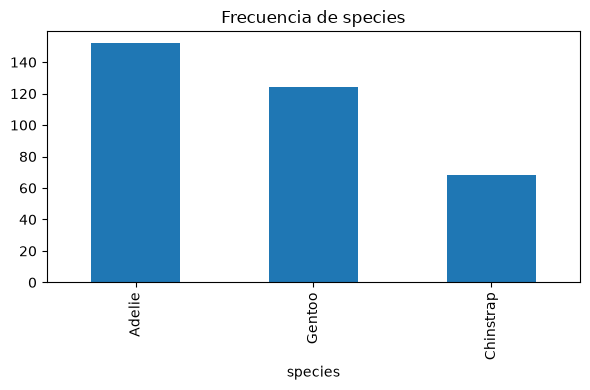

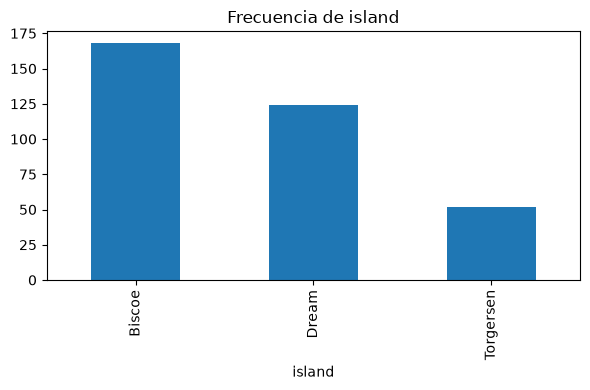

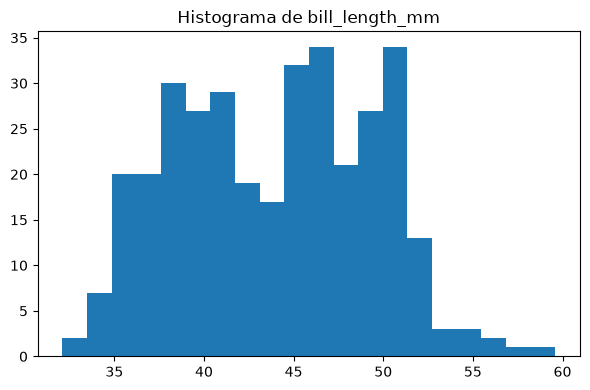

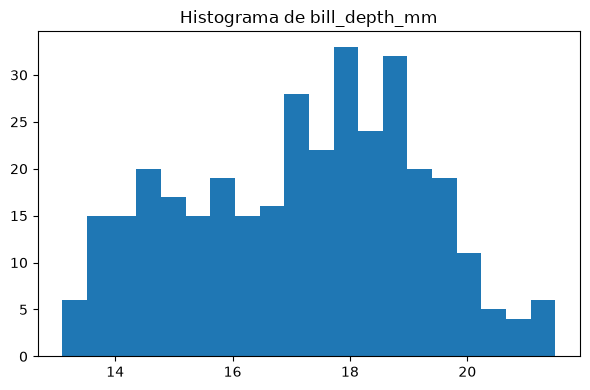

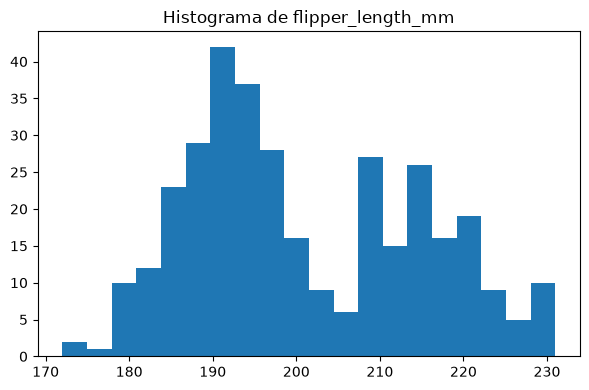

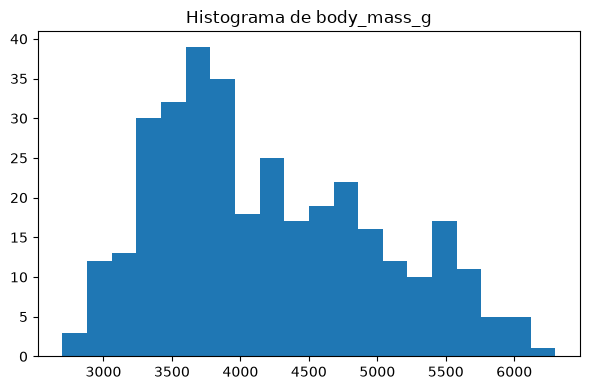

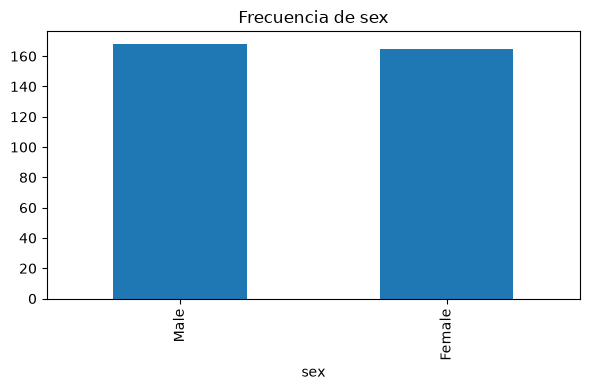

In [19]:
penguins = sns.load_dataset("penguins")

graficos_automaticos(penguins)

### 2. Carga el archivo matriz_distancias.xlsx en Pandas, de forma que los nombres de las filas y columnas correspondan a las ciudades.

Elimina Las Palmas de Gran Canaria y Palma, ya que queremos realizar el recorrido en coche.

Fuente: Mejores Rutas

Nos interesa visitar todas las principales ciudades de España recorriendo la menor distancia posible.

No es necesario que obtengas la solución óptima; se busca que desarrolles una solución razonable utilizando las herramientas que tienes actualmente.

Por ejemplo, una aproximación sencilla (aunque no óptima) sería visitar siempre la ciudad más cercana que todavía no haya sido visitada.

Crea una función que, dada la matriz de distancias y una ciudad de origen:

proponga una ruta lo más corta posible,
devuelva una lista con el orden de visita,
e indique la distancia total recorrida.

(EXTRA) ¿Desde qué ciudad sería más corta la ruta utilizando el algoritmo propuesto?

In [ ]:
# Cargar la matriz de distancias
distancias = pd.read_excel(
    "matriu_distancies.xlsx",
    index_col=0
)

# Eliminar Palma y Las Palmas
distancias = distancias.drop(
    index=["Palma", "Las Palmas de Gran Canaria"],
    columns=["Palma", "Las Palmas de Gran Canaria"]
)

# Función para calcular la ruta usando el algoritmo del vecino más cercano
def ruta_greedy(matriz, origen):

    ciudad_actual = origen          # Ciudad desde la que empezamos
    visitadas = [origen]            # Lista de ciudades visitadas
    distancia_total = 0             # Distancia recorrida

    while len(visitadas) < len(matriz):

        # Distancias desde la ciudad actual a las ciudades no visitadas
        disponibles = matriz.loc[ciudad_actual].drop(visitadas)

        # Ciudad más cercana
        siguiente = disponibles.idxmin()

        distancia_total += disponibles.min()
      
        visitadas.append(siguiente)

        ciudad_actual = siguiente

    return visitadas, distancia_total


# Calcular una ruta empezando desde Barcelona
ruta, km = ruta_greedy(distancias, "Barcelona")

print("Ruta propuesta:")

for ciudad in ruta:
    print(ciudad)

print(f"\nDistancia total: {km} km")


# la ciudad con mejor posicion de salida
mejor_ciudad = None
mejor_distancia = float("inf")

for ciudad in distancias.index:

    ruta, km = ruta_greedy(distancias, ciudad)

    if km < mejor_distancia:
        mejor_distancia = km
        mejor_ciudad = ciudad

print("\nMejor ciudad de salida:", mejor_ciudad)
print("Distancia total:", mejor_distancia, "km")

Ruta propuesta:
Barcelona
Hospitalet de Llobregat
Zaragoza
Valencia
Alicante
Murcia
Córdoba
Sevilla
Málaga
Valladolid
Gijón
Bilbao
Vigo

Distancia total: 2778.0 km

Mejor ciudad de salida: Barcelona
Distancia total: 2778.0 km
